# Neural Networks: Feed-Forward MLP

**Dataset:** Digits (sklearn built-in)  
**Task:** Multiclass classification — recognize handwritten digits 0–9

---

## Overview

A **Multi-Layer Perceptron (MLP)** is a fully-connected feed-forward neural network. Information flows in one direction: input → hidden layers → output.

### Architecture

For a network with layers $L_0, L_1, \ldots, L_N$:

$$\mathbf{a}^{(l)} = f\!\left(\mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

where $f$ is an **activation function** applied element-wise.

### Activation Functions

| Function | Formula | Use Case |
|----------|---------|----------|
| ReLU | $\max(0, z)$ | Hidden layers (most common) |
| Sigmoid | $\frac{1}{1+e^{-z}}$ | Binary output |
| Softmax | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | Multiclass output |
| Tanh | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | Hidden layers (zero-centered) |

### Backpropagation

We compute gradients of the loss with respect to every weight using the **chain rule**:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{(l)}} \cdot \frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{z}^{(l)}} \cdot \frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{W}^{(l)}}$$

### Optimization

- **SGD**: $\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$ (simple, noisy)
- **Adam**: adapts per-parameter learning rates using first and second moment estimates (faster, widely used)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams['font.size'] = 12

## 2. MLP from Scratch

We implement a 2-hidden-layer MLP with ReLU activations and softmax output, trained with mini-batch SGD.

In [2]:
class MLP:
    """2-hidden-layer MLP trained with mini-batch SGD."""

    def __init__(self, layer_sizes, lr=0.01, n_epochs=100, batch_size=64):
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.train_loss_  = []
        self.val_loss_    = []
        self.train_acc_   = []
        self.val_acc_     = []

    def _init_weights(self):
        self.W, self.b = [], []
        for i in range(len(self.layer_sizes) - 1):
            n_in, n_out = self.layer_sizes[i], self.layer_sizes[i+1]
            # He initialization for ReLU layers
            self.W.append(np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in))
            self.b.append(np.zeros(n_out))

    @staticmethod
    def _relu(z):    return np.maximum(0, z)

    @staticmethod
    def _relu_grad(z): return (z > 0).astype(float)

    @staticmethod
    def _softmax(z):
        z_shifted = z - z.max(axis=1, keepdims=True)
        e = np.exp(z_shifted)
        return e / e.sum(axis=1, keepdims=True)

    def _forward(self, X):
        self._a = [X]
        self._z = []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = self._a[-1] @ W + b
            self._z.append(z)
            if i < len(self.W) - 1:
                self._a.append(self._relu(z))
            else:
                self._a.append(self._softmax(z))
        return self._a[-1]

    def _cross_entropy(self, p, y_onehot):
        return -np.mean(np.sum(y_onehot * np.log(p + 1e-15), axis=1))

    def _backward(self, y_onehot):
        n = y_onehot.shape[0]
        # Output layer gradient
        delta = (self._a[-1] - y_onehot) / n
        dW = [None] * len(self.W)
        db = [None] * len(self.b)

        for i in reversed(range(len(self.W))):
            dW[i] = self._a[i].T @ delta
            db[i] = delta.sum(axis=0)
            if i > 0:
                delta = (delta @ self.W[i].T) * self._relu_grad(self._z[i-1])

        for i in range(len(self.W)):
            self.W[i] -= self.lr * dW[i]
            self.b[i] -= self.lr * db[i]

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n_classes = len(np.unique(y_train))
        self.layer_sizes = [X_train.shape[1]] + self.layer_sizes + [n_classes]
        self._init_weights()

        def one_hot(y):
            oh = np.zeros((len(y), n_classes))
            oh[np.arange(len(y)), y] = 1
            return oh

        for epoch in range(self.n_epochs):
            # Shuffle
            idx = np.random.permutation(len(X_train))
            for start in range(0, len(X_train), self.batch_size):
                batch = idx[start:start + self.batch_size]
                Xb, yb = X_train[batch], y_train[batch]
                self._forward(Xb)
                self._backward(one_hot(yb))

            # Record metrics
            p_train = self._forward(X_train)
            self.train_loss_.append(self._cross_entropy(p_train, one_hot(y_train)))
            self.train_acc_.append(np.mean(p_train.argmax(1) == y_train))

            if X_val is not None:
                p_val = self._forward(X_val)
                self.val_loss_.append(self._cross_entropy(p_val, one_hot(y_val)))
                self.val_acc_.append(np.mean(p_val.argmax(1) == y_val))

        return self

    def predict(self, X):
        return self._forward(X).argmax(axis=1)

## 3. Load and Preprocess Digits

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_s)
X_val_s   = scaler.transform(X_val_s)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape[0]} | Val: {X_val_s.shape[0]} | Test: {X_test_s.shape[0]}")

Train: 1221 | Val: 216 | Test: 360


## 4. Train the MLP

In [4]:
mlp = MLP(layer_sizes=[128, 64], lr=0.05, n_epochs=150, batch_size=64)
mlp.fit(X_train_s, y_train_s, X_val=X_val_s, y_val=y_val_s)

train_acc = np.mean(mlp.predict(X_train_s) == y_train_s)
test_acc  = np.mean(mlp.predict(X_test_s)  == y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

Train accuracy: 1.0000
Test  accuracy: 0.9667


## 5. Training Curves

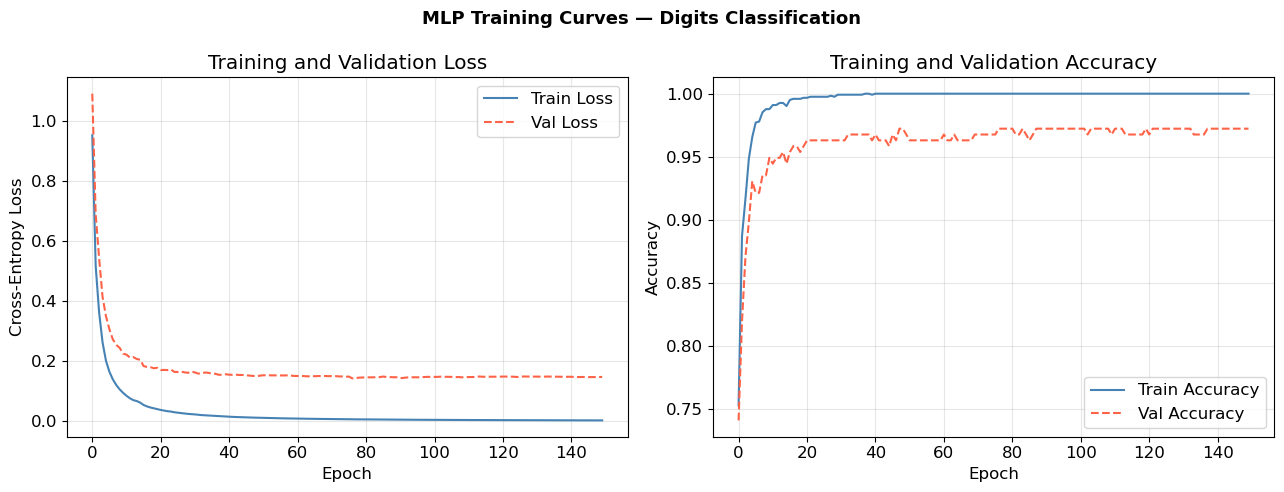

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mlp.train_loss_, label='Train Loss', color='steelblue')
axes[0].plot(mlp.val_loss_,   label='Val Loss',   color='tomato', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(mlp.train_acc_, label='Train Accuracy', color='steelblue')
axes[1].plot(mlp.val_acc_,   label='Val Accuracy',   color='tomato', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('MLP Training Curves — Digits Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Confusion Matrix

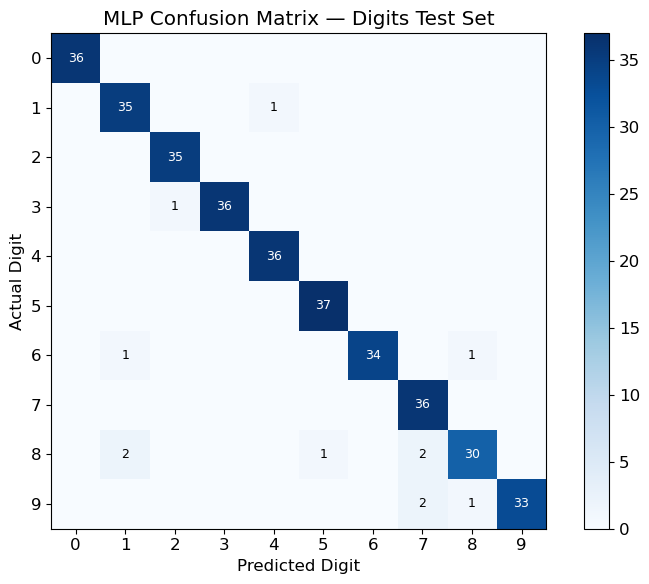

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.94      0.97        36
           7       0.90      1.00      0.95        36
           8       0.94      0.86      0.90        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [6]:
y_pred = mlp.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted Digit'); ax.set_ylabel('Actual Digit')
ax.set_title('MLP Confusion Matrix — Digits Test Set')
for i in range(10):
    for j in range(10):
        if cm[i,j] > 0:
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=9)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

## 7. Compare Architectures

In [7]:
architectures = {
    'No hidden layer (linear)':     (100, 32),
    '1 layer [64]':                 (150, 64),
    '2 layers [128, 64]':           (150, 128, 64),
    '2 layers [256, 128]':          (150, 256, 128),
    '3 layers [256, 128, 64]':      (150, 256, 128, 64),
}

# Use sklearn MLPClassifier for fair comparison
from sklearn.neural_network import MLPClassifier

X_tr_full = scaler.fit_transform(X_train)
X_te_full = scaler.transform(X_test)

print(f"{'Architecture':40s} | Test Accuracy")
print("-" * 55)

for name, hidden_layer_sizes in [
    ('Logistic (no hidden)', ()),
    ('1 layer [64]', (64,)),
    ('2 layers [128, 64]', (128, 64)),
    ('2 layers [256, 128]', (256, 128)),
    ('3 layers [256, 128, 64]', (256, 128, 64)),
]:
    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42
    )
    clf.fit(X_tr_full, y_train)
    acc = clf.score(X_te_full, y_test)
    print(f"{name:40s} | {acc:.4f}")

Architecture                             | Test Accuracy
-------------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Logistic (no hidden)                     | 0.9583
1 layer [64]                             | 0.9806
2 layers [128, 64]                       | 0.9694
2 layers [256, 128]                      | 0.9778
3 layers [256, 128, 64]                  | 0.9806


## 8. Effect of Regularization (Dropout via sklearn alpha)

**L2 regularization** (weight decay) penalizes large weights, preventing overfitting:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \frac{\alpha}{2} \sum_l \|\mathbf{W}^{(l)}\|_F^2$$

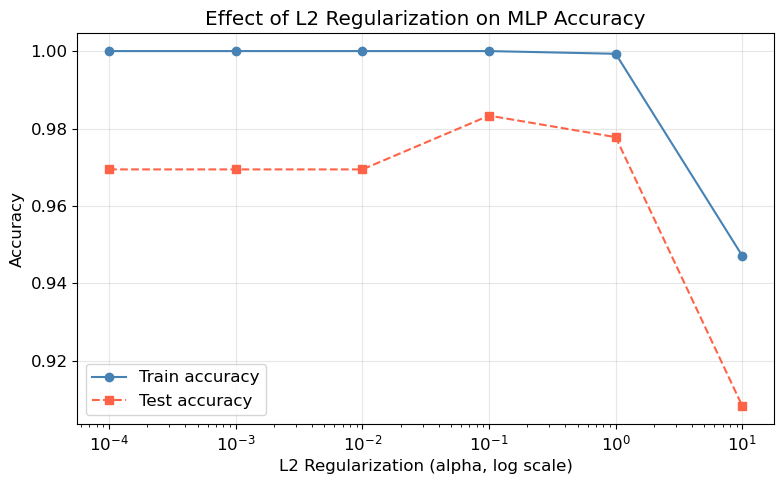

In [8]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
train_accs, test_accs = [], []

for alpha in alphas:
    clf = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=alpha,
        max_iter=300,
        random_state=42
    )
    clf.fit(X_tr_full, y_train)
    train_accs.append(clf.score(X_tr_full, y_train))
    test_accs.append(clf.score(X_te_full,  y_test))

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, train_accs, 'o-', color='steelblue', label='Train accuracy')
plt.semilogx(alphas, test_accs,  's--', color='tomato',    label='Test accuracy')
plt.xlabel('L2 Regularization (alpha, log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of L2 Regularization on MLP Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

### Key Takeaways

- An MLP transforms inputs through a series of **linear + nonlinear** operations; each layer learns increasingly abstract representations.
- **ReLU** is the standard hidden-layer activation — it avoids the vanishing gradient problem of sigmoid/tanh.
- **Backpropagation** efficiently computes all gradients via the chain rule in $O(n \cdot d)$ where $d$ is total parameter count.
- **Mini-batch SGD** provides a good balance between gradient noise and computational efficiency.
- **Adam optimizer** adapts per-parameter learning rates and converges faster than vanilla SGD.
- **L2 regularization** (weight decay) reduces overfitting by penalizing large weights.
- Deeper networks can model more complex functions, but require careful regularization and more data.
- Always **standardize** inputs — gradient descent is sensitive to feature scale.